In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 表示設定（任意）
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [23]:
# === 入力先の指定 ===
# A) フォルダに .csv / .ods が入っている場合
DATA_DIR = "/scratch/rs02358/ved_dissertation/CCEdit/outputs/tv2v/ALL"   # ここをあなたのフォルダに変更

# B) 個別ファイルを明示指定する場合（使うならコメントを外す）
# FILES = [
#     "./results/ccedit_exp1.csv",
#     "./results/ccedit_exp2.ods",
# ]

# 必須列（列名はこの通りのスペル/大文字小文字で）
REQUIRED_COLS = ["video_id", "CLIP Score", "Temporal Consistency", "PickScore"]


In [24]:
def load_files(data_dir=None, files=None):
    paths = []
    if files is not None:
        paths = [Path(p) for p in files]
    elif data_dir is not None:
        data_dir = Path(data_dir)
        paths = list(data_dir.glob("*.csv")) + list(data_dir.glob("*.ods"))
    else:
        raise ValueError("Please set either DATA_DIR or FILES.")

    if not paths:
        raise FileNotFoundError("No .csv or .ods files found. Check your paths.")

    frames = []
    for p in paths:
        try:
            # もし .ods がカンマ区切りでない場合は delimiter= を調整
            df = pd.read_csv(p)
        except Exception as e:
            raise RuntimeError(f"Failed to read {p}: {e}")
        df["__source_file"] = str(p)
        frames.append(df)

    data = pd.concat(frames, ignore_index=True)

    # 必須列の確認
    missing = [c for c in REQUIRED_COLS if c not in data.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Found columns: {list(data.columns)}")

    # 数値列を numeric 化（不正値は NaN → drop）
    for col in ["CLIP Score", "Temporal Consistency", "PickScore"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    before = len(data)
    data = data.dropna(subset=["CLIP Score", "Temporal Consistency", "PickScore", "video_id"])
    after = len(data)
    if after < before:
        print(f"Dropped {before - after} rows due to missing/non-numeric required values.")

    # video_id を文字列に統一
    data["video_id"] = data["video_id"].astype(str)
    return data


In [25]:
FILES = globals().get("FILES", None)  # FILES を使っていなければ None
all_data = load_files(DATA_DIR, FILES)

print(f"Loaded {len(all_data)} rows from {all_data['__source_file'].nunique()} file(s).")
all_data.head()


Loaded 240 rows from 1 file(s).


,Timestamp,video_id,Filename,Prompt,rfc,cfg,CLIP Score,PickScore,Temporal Consistency,Embedding Distance,Unnamed: 10,__source_file
0,2025-08-13 12:42:44,ApplyMakeup,animation-0000.mp4,A focused woman carefully applies eyeliner wit...,0.3,5,0.2251,16.6921,0.9684,0.7712,NaN,/scratch/rs02358/ved_dissertation/CCEdit/outpu...
1,2025-08-13 12:42:59,ApplyMakeup,animation-0003_prior0.1.mp4,A focused woman carefully applies eyeliner wit...,0.1,5,0.2819,16.6537,0.9198,0.7077,NaN,/scratch/rs02358/ved_dissertation/CCEdit/outpu...
2,2025-08-13 12:43:17,ApplyMakeup,animation-0002_cfg9.mp4,A focused woman carefully applies eyeliner wit...,0.3,9,0.2269,17.0815,0.9671,0.7704,NaN,/scratch/rs02358/ved_dissertation/CCEdit/outpu...
3,2025-08-13 12:43:28,ApplyMakeup,animation-0006_prior0.1_cfg9.mp4,A focused woman carefully applies eyeliner wit...,0.1,9,0.2765,17.3133,0.9132,0.7142,NaN,/scratch/rs02358/ved_dissertation/CCEdit/outpu...
4,2025-08-13 12:43:51,ApplyMakeup,animation-0001_cfg12.mp4,A focused woman carefully applies eyeliner wit...,0.3,12,0.2494,16.9491,0.9604,0.7463,NaN,/scratch/rs02358/ved_dissertation/CCEdit/outpu...


In [26]:
agg = (
    all_data
    .groupby("video_id", as_index=False)
    .agg({
        "CLIP Score": ["mean", "std"],
        "Temporal Consistency": ["mean", "std"],
        "PickScore": ["mean", "std"],
    })
)

# 列名をフラット化
agg.columns = [
    "video_id",
    "CLIP Score_mean", "CLIP Score_std",
    "Temporal Consistency_mean", "Temporal Consistency_std",
    "PickScore_mean", "PickScore_std"
]

# 読みやすく並べ替え
agg = agg.sort_values("video_id").reset_index(drop=True)
agg


,video_id,CLIP Score_mean,CLIP Score_std,Temporal Consistency_mean,Temporal Consistency_std,PickScore_mean,PickScore_std
0,ApplyMakeup,0.256033,0.030011,0.949200,0.029168,17.238821,0.501077
1,BoxingPunchingBag,0.349908,0.016980,0.924333,0.031476,18.339150,0.590504
2,BrushingTeeth,0.342658,0.019561,0.935858,0.016733,18.749875,0.732483
3,CleanAndJerk,0.311392,0.016969,0.912758,0.027500,17.924183,0.645922
4,Fencing,0.362158,0.012316,0.924263,0.033557,19.362425,0.416833
5,GolfSwing,0.311917,0.021508,0.961925,0.017798,19.532917,0.741453
6,HandstandWalking,0.302342,0.017404,0.956758,0.016495,19.152833,0.533429
7,HorseRiding,0.289333,0.018759,0.922512,0.034731,18.094996,0.671081
8,RockClimbingIndoor,0.303617,0.028478,0.922967,0.019931,18.320092,0.413019
9,SkateBoarding,0.323596,0.018639,0.889463,0.023951,18.485112,0.381143


In [33]:
def iqr(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    return q3 - q1, q1, q3

results = {}

for metric_mean_col, label in [
    ("CLIP Score_mean", "CLIP Score (per-video mean)"),
    ("PickScore_mean", "PickScore (per-video mean)"),
]:
    vals = agg[metric_mean_col].values
    the_iqr, q1, q3 = iqr(vals)
    results[label] = {
        "N_videos": len(vals),
        "Min": float(np.min(vals)),
        "Q1": float(q1),
        "Median": float(np.median(vals)),
        "Mean": float(np.mean(vals)),
        "Q3": float(q3),
        "Max": float(np.max(vals)),
        "IQR": float(the_iqr),
    }

iqr_df = pd.DataFrame(results).T
iqr_df




,N_videos,Min,Q1,Median,Mean,Q3,Max,IQR
CLIP Score (per-video mean),10.0,0.256033,0.30266,0.311654,0.315295,0.337893,0.362158,0.035232
PickScore (per-video mean),10.0,17.238821,18.15127,18.412131,18.520040,19.052094,19.532917,0.900824


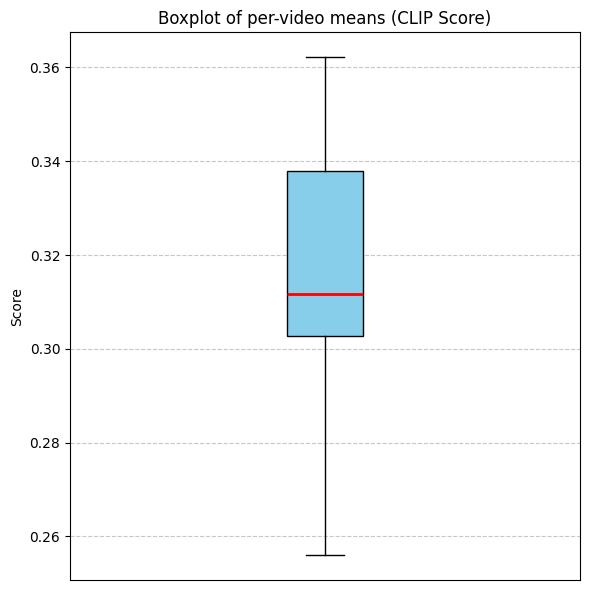

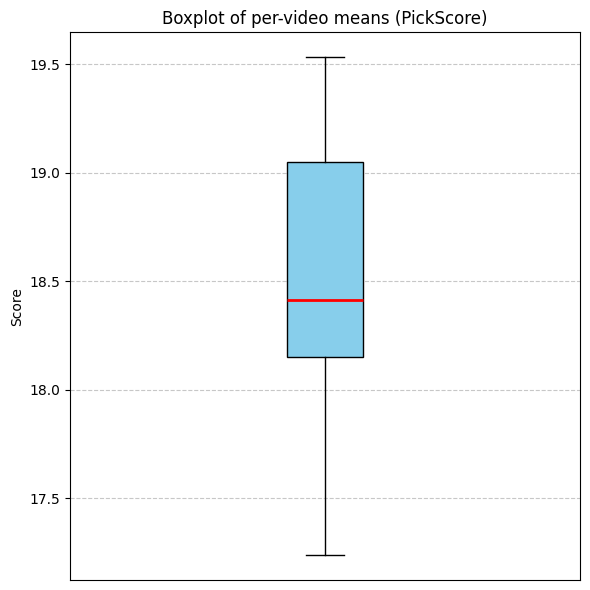

In [39]:
# --- IQR 可視化 (箱ひげ図, per-video mean の分布, 個別表示) ---
metrics_to_plot = [
    ("CLIP Score_mean", "Boxplot of per-video means (CLIP Score)"),
    ("PickScore_mean", "Boxplot of per-video means (PickScore)")
]

for metric_col, title in metrics_to_plot:
    vals = agg[metric_col].values

    plt.figure(figsize=(6, 6))
    plt.boxplot(vals, vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue", color="black"),
                medianprops=dict(color="red", linewidth=2),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, color="gray", alpha=0.6))

    plt.title(title)
    plt.ylabel("Score")
    # 下部ラベルを非表示
    plt.xticks([])
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


In [28]:
from pathlib import Path

OUTDIR = Path("./outputs_summary")
OUTDIR.mkdir(parents=True, exist_ok=True)

per_video_path = OUTDIR / "per_video_mean_sd.csv"
iqr_path = OUTDIR / "iqr_from_per_video_means.csv"

agg.to_csv(per_video_path, index=False)
iqr_df.to_csv(iqr_path)

print("Saved:")
print(per_video_path.resolve())
print(iqr_path.resolve())


Saved:
/user/HS402/rs02358/Documents/Dissertation/outputs_summary/per_video_mean_sd.csv
/user/HS402/rs02358/Documents/Dissertation/outputs_summary/iqr_from_per_video_means.csv


/tmp/ipykernel_2356643/2190294936.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_lists, labels=vids, showfliers=True)


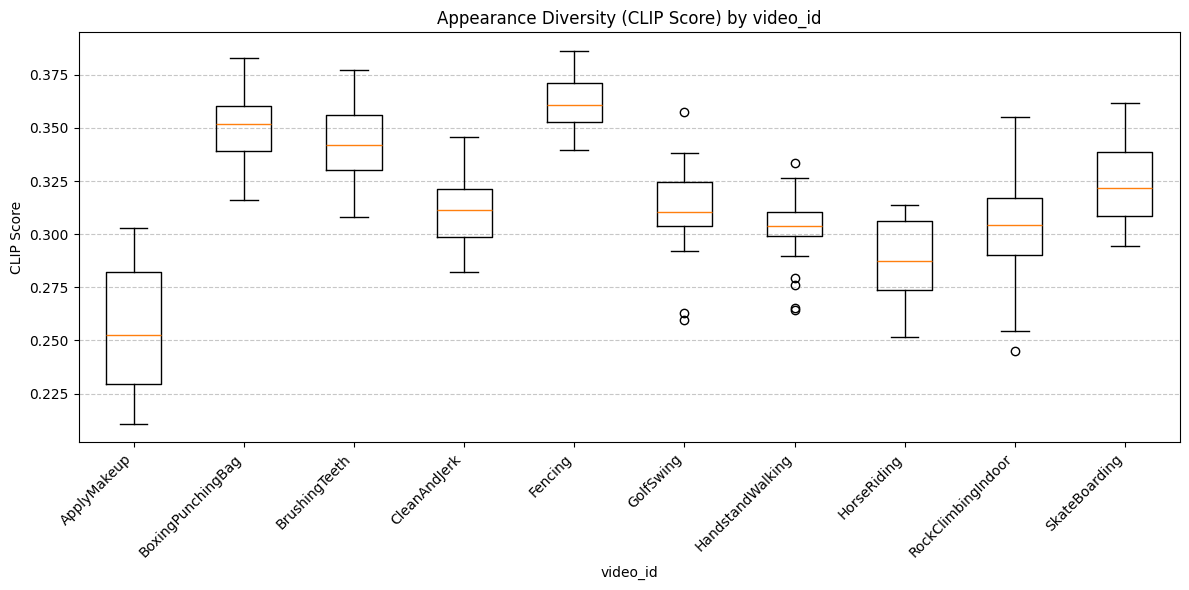

/tmp/ipykernel_2356643/2190294936.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_lists, labels=vids, showfliers=True)


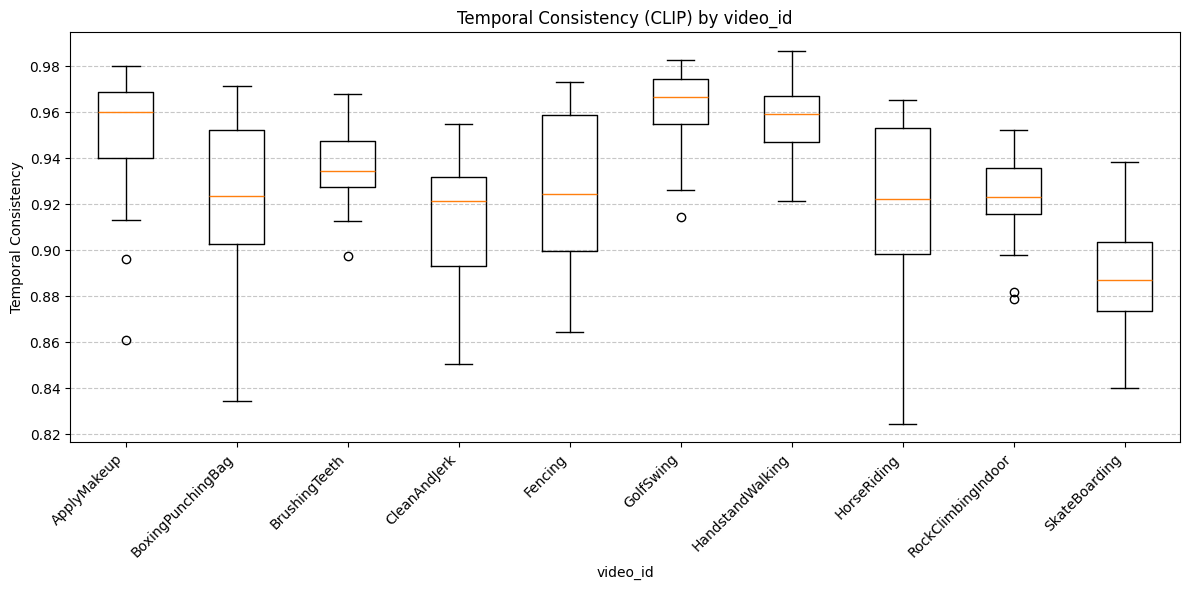

/tmp/ipykernel_2356643/2190294936.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_lists, labels=vids, showfliers=True)


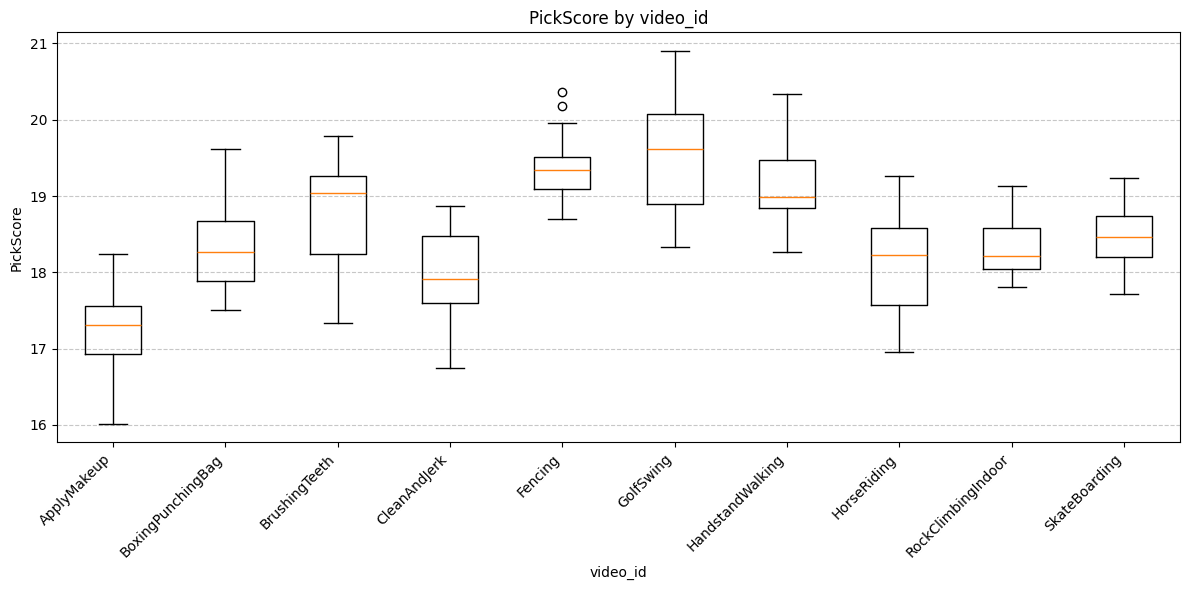

In [40]:
def boxplot_by_video(df, value_col, title):
    vids = sorted(df["video_id"].unique(), key=lambda x: str(x))
    data_lists = [df.loc[df["video_id"] == v, value_col].values for v in vids]

    plt.figure(figsize=(12, 6))
    plt.boxplot(data_lists, labels=vids, showfliers=True)
    plt.xlabel("video_id")
    plt.ylabel(value_col)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

# Appearance Diversity（CLIP Score）
boxplot_by_video(all_data, "CLIP Score", "Appearance Diversity (CLIP Score) by video_id")

# Temporal Consistency
boxplot_by_video(all_data, "Temporal Consistency", "Temporal Consistency (CLIP) by video_id")

# PickScore
boxplot_by_video(all_data, "PickScore", "PickScore by video_id")
